In this example script we give example usages for many of the functions available in the HolograPy package. We are modelling an array of transducers, outputting soundwaves towards an acoustic modulator (an acoustic metamaterial, for example). The modulator reconfigures the sound field such that when it is propagated to the far field, we see a hologrpahic image of the letter "U".

In [21]:
import numpy as np
import plotly.graph_objects as go
from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import HolograPy as hp # <--------- Our package!

Firstly, we define the basic physical parameters of the sound fields we will be working with. Speed of sound, operating frequency and wavelength, etc...

In [22]:
# physics params
c0 = 343.  # [m/s]
f = 40000
lam = c0/f
k = 2*np.pi/lam

Now we define a set of points for our transducers, modulator and evaluation plane using the compute_grid_2d function. The compute_grid_3d function can also be used if a volume rather than a plane needs to be defined.

In [ ]:
# Define transducer plane
t_v1, t_v2 = [1,0,0], [0,1,0]
t_spacingx, t_spacingy = 10/1000, 10/1000
t_nx, t_ny = 16, 16
t_origin = [t_spacingx/2-t_spacingx * t_nx/2,
            t_spacingy/2-t_spacingy * t_ny/2,
            120/1000] # at (0, 120/1000, 0)
t_radius = 4.5/1000
t_normals = [0, 0, -1] # all transducers are facing in -z direction.
t_points = hp.compute_grid_2d(t_origin, t_v1, t_v2, t_spacingx, t_spacingy, t_nx, t_ny)

# Define reflector plane - mirror of the transducer plane
r_v1, r_v2 = [1,0,0], [0,1,0]
r_spacingx, r_spacingy = 10/1000, 10/1000
r_nx, r_ny = 16, 16
r_origin = [r_spacingx/2-r_spacingx * r_nx/2,
            r_spacingy/2-r_spacingy * r_ny/2,
            0] # at (0, 0, 0)
r_radius = 4.5/1000
r_normals = [0, 0, 1] # all reflector elements are facing in +z direction.
r_points = hp.compute_grid_2d(r_origin, r_v1, r_v2, r_spacingx, r_spacingy, r_nx, r_ny)


# Define evaluation plane
e_v1, e_v2 = [1,0,0], [0,0,1]
e_spacingx, e_spacingz = 1/1000, 1/1000
e_nx, e_nz = 120, 120
e_origin = [e_spacingx/2-e_spacingx * e_nx/2,
            0,
            0,
            ]
e_points = hp.compute_grid_2d(e_origin, e_v1, e_v2, e_spacingx, e_spacingz, e_nx, e_nz)

To visualise these planes, we can use the plotly package. We have functions to visualise arrays of transducers, generic points or the edges of a plane.

In [33]:
# lets define our focal point(s)
f_points = [[0, 0, 60/1000]]

In [ ]:
fig = go.Figure()

hp.plot_transducers_plotly(fig, t_points, t_radius, label="Transducers")
hp.plot_plane_edges_plotly(fig, r_points, color='red', label="Reflector plane")
hp.plot_plane_edges_plotly(fig, e_points, color='slateblue', label="Evaluation plane")

fig.add_trace(go.Scatter3d(x=[f_points[0][0]],
                           y=[f_points[0][1]],
                           z=[f_points[0][2]],
                           mode='markers',
                           name='focus',
                           marker=dict(symbol='x',
                                       size=2,
                                       color='orange',
                                       line=dict(width=4))))

fig.update_layout(
    scene=dict(
        xaxis=dict(showgrid=False),
        yaxis=dict(showgrid=False),
        zaxis=dict(showgrid=False),
        # aspectmode='data'  # equal scaling for all axes
    ),
    width=700,
    height=700,
    showlegend=True
)

fig.show()

In [47]:
# find forward model for the board/reflector and focus
H_t_focus = hp.PM_forward_model(np.array(f_points), t_points, t_normals, k)
H_r_focus = hp.PM_forward_model(np.array(f_points), r_points, r_normals, k)

# we set the pressure at the focus
P_focus = np.ones(len(f_points))*np.exp(1j*np.ones(len(f_points)))

# find the pressure activations for each of the boards
P_t = P_focus @ np.conj(H_t_focus)
P_r = P_focus @ np.conj(H_r_focus)

# REMEMBER TO CONSTRAIN THE AMPLITUDES BACK DOWN TO 1
P_t = np.ones_like(P_t)*np.exp(1j*np.angle(P_t))
P_r = np.ones_like(P_r)*np.exp(1j*np.angle(P_r))

# find forward model for each board and the evaluation plane
H_t_eval = hp.PM_forward_model(e_points, t_points, t_normals, k)
H_r_eval = hp.PM_forward_model(e_points, r_points, r_normals, k)

# Propagate from the board/reflector to evaluation plane
P_t_eval = (H_t_eval @ P_t).reshape(e_nx, e_nz)
P_r_eval = (H_r_eval @ P_r).reshape(e_nx, e_nz)

# sum the contributions from both board + reflector
P_eval = P_t_eval + P_r_eval

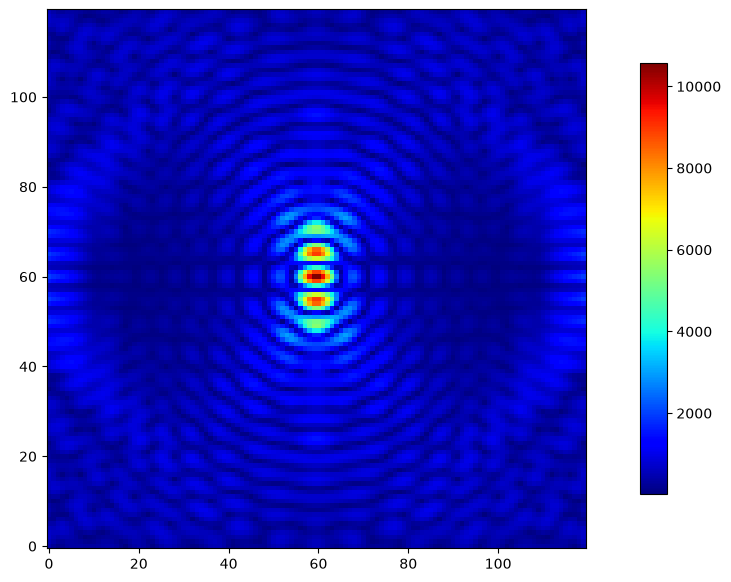

In [48]:
# Plotting

# ex = [-500, 500, 0, 240]

fix, ax = plt.subplots(1, 1, figsize=(7, 7))

im = ax.imshow(abs(P_eval), cmap=plt.get_cmap('jet'), origin='lower')

cax = ax.inset_axes([1.1, .1, 0.05, 0.8]) # [x0, y0, width, height]
plt.colorbar(im, cax=cax)

plt.show()